# British Airlines - Forage - Task 2

## Predictive Modeling of Customer Bookings

By: Jack Leniart


----------------------

### Exploratory Data Analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
#Update values for flight_day
#Map string values to integers for each day of the week
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [8]:
#Create a correlation matrix to see how closely the numeric variables are correlated
num_df = df[['num_passengers','purchase_lead','length_of_stay','flight_hour','flight_day','flight_duration']]
booking_corr = num_df.corr()
booking_corr

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,flight_duration
num_passengers,1.000000,0.212606,-0.115850,0.015607,0.015407,-0.063169
purchase_lead,0.212606,1.000000,-0.076560,0.035973,0.036531,0.067866
length_of_stay,-0.115850,-0.076560,1.000000,-0.024872,-0.000310,0.141181
flight_hour,0.015607,0.035973,-0.024872,1.000000,0.024086,-0.002101
flight_day,0.015407,0.036531,-0.000310,0.024086,1.000000,0.018434
flight_duration,-0.063169,0.067866,0.141181,-0.002101,0.018434,1.000000


Our numeric variables are not strongly correlated at all.

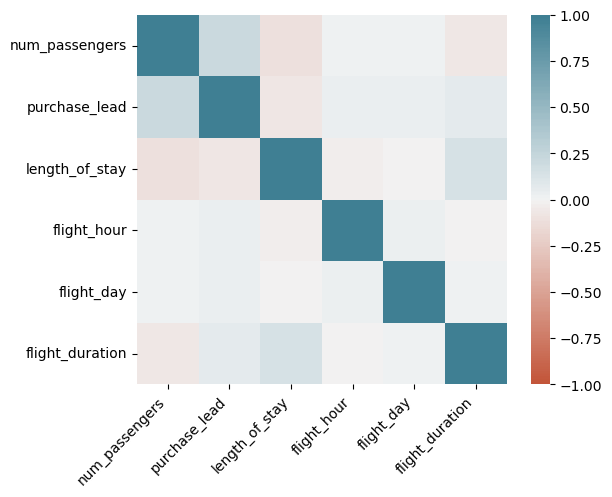

In [9]:
#Create a heatmap to represent the correlation matrix
import seaborn as sns
ax = sns.heatmap(
    booking_corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

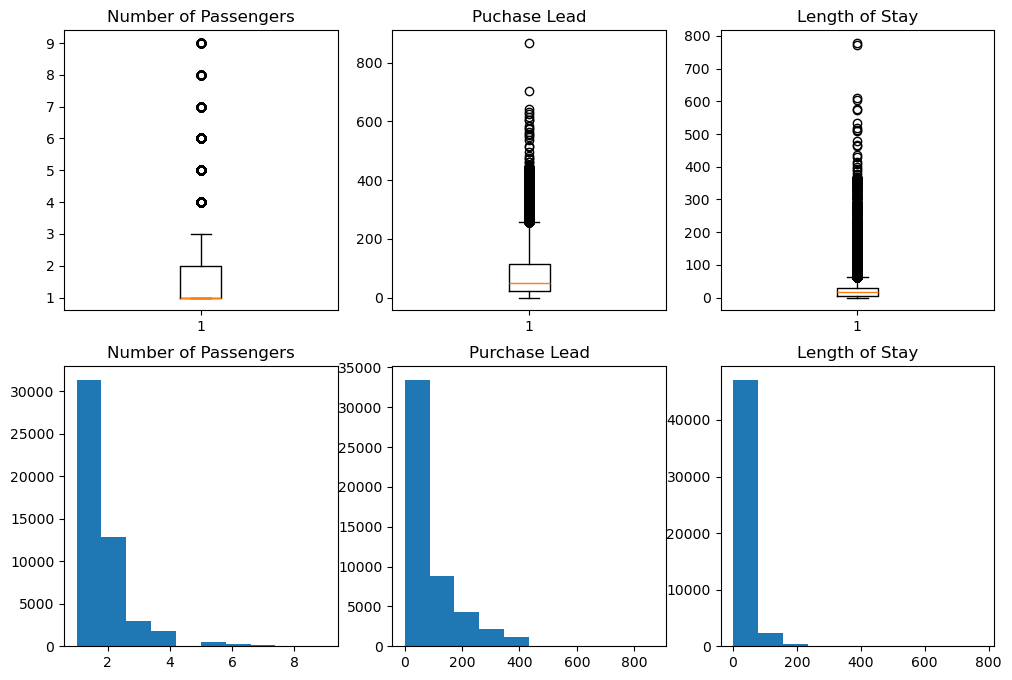

In [10]:
#Check the distribution of each numeric variable by generating box plots and histograms
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(12,8))
axs[0,0].boxplot(df["num_passengers"])
axs[0,0].set_title("Number of Passengers")
axs[1,0].hist(df["num_passengers"])
axs[1,0].set_title("Number of Passengers")
axs[0,1].boxplot(df["purchase_lead"])
axs[0,1].set_title("Puchase Lead")
axs[1,1].hist(df["purchase_lead"])
axs[1,1].set_title("Purchase Lead")
axs[0,2].boxplot(df["length_of_stay"])
axs[0,2].set_title("Length of Stay")
axs[1,2].hist(df["length_of_stay"])
axs[1,2].set_title("Length of Stay")
plt.show()

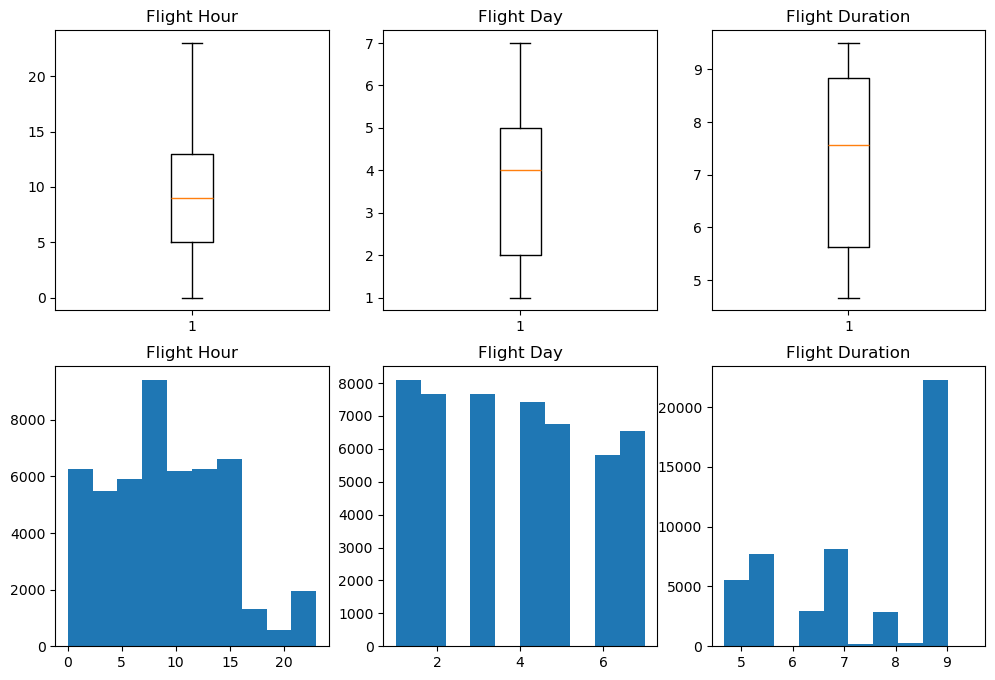

In [11]:
#Check the distribution of each numeric variable by generating box plots and histograms
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(12,8))
axs[0,0].boxplot(df["flight_hour"])
axs[0,0].set_title("Flight Hour")
axs[1,0].hist(df["flight_hour"])
axs[1,0].set_title("Flight Hour")
axs[0,1].boxplot(df["flight_day"])
axs[0,1].set_title("Flight Day")
axs[1,1].hist(df["flight_day"])
axs[1,1].set_title("Flight Day")
axs[0,2].boxplot(df["flight_duration"])
axs[0,2].set_title("Flight Duration")
axs[1,2].hist(df["flight_duration"])
axs[1,2].set_title("Flight Duration")
plt.show()

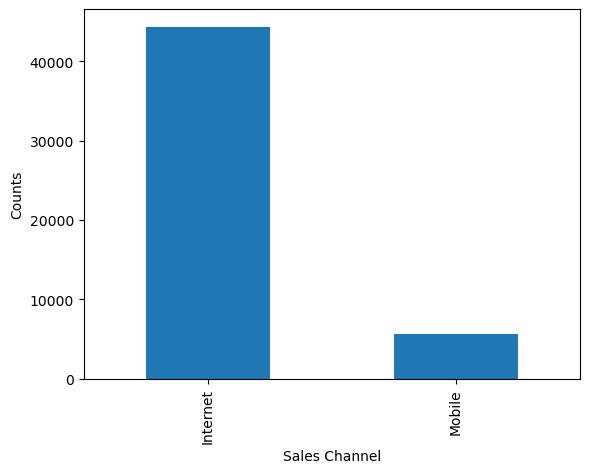

In [12]:
#Check the value counts of the categorical variables
counts = df["sales_channel"].value_counts()
counts.plot(kind='bar')
plt.xlabel('Sales Channel')
plt.ylabel('Counts')
plt.show()

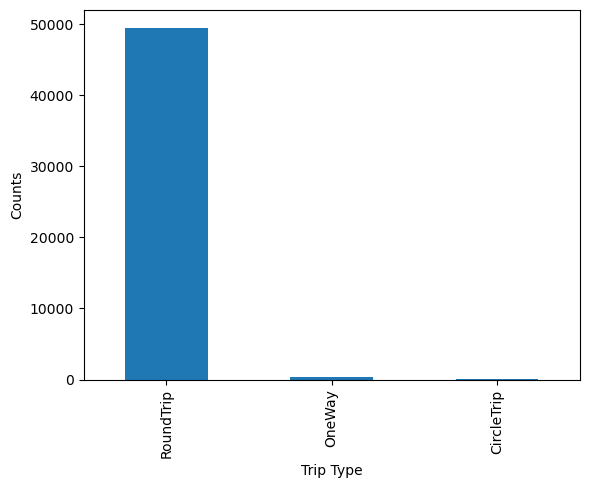

In [13]:
#Check the value counts of the categorical variables
counts = df["trip_type"].value_counts()
counts.plot(kind='bar')
plt.xlabel('Trip Type')
plt.ylabel('Counts')
plt.show()

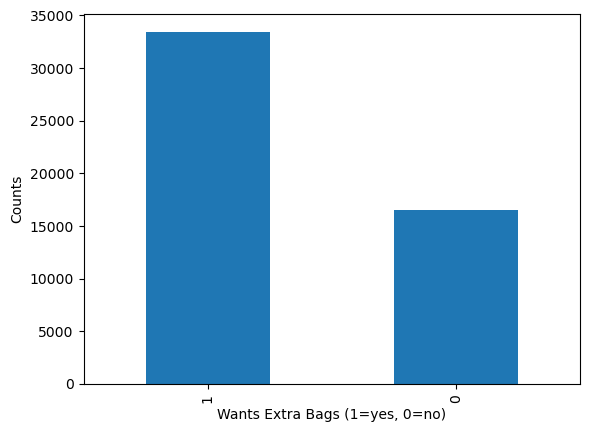

In [14]:
#Check the value counts of the categorical variables
counts = df["wants_extra_baggage"].value_counts()
counts.plot(kind='bar')
plt.xlabel('Wants Extra Bags (1=yes, 0=no)')
plt.ylabel('Counts')
plt.show()

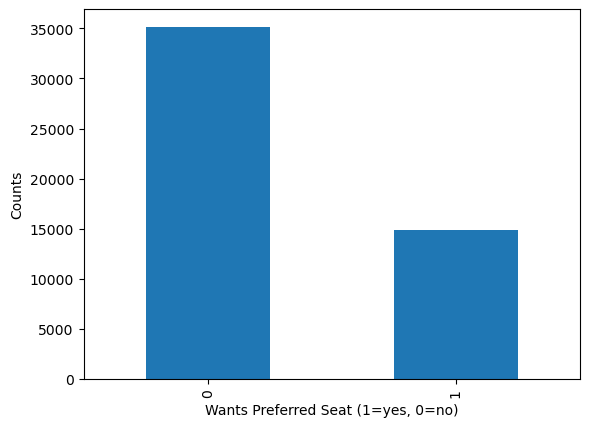

In [15]:
#Check the value counts of the categorical variables
counts = df["wants_preferred_seat"].value_counts()
counts.plot(kind='bar')
plt.xlabel('Wants Preferred Seat (1=yes, 0=no)')
plt.ylabel('Counts')
plt.show()

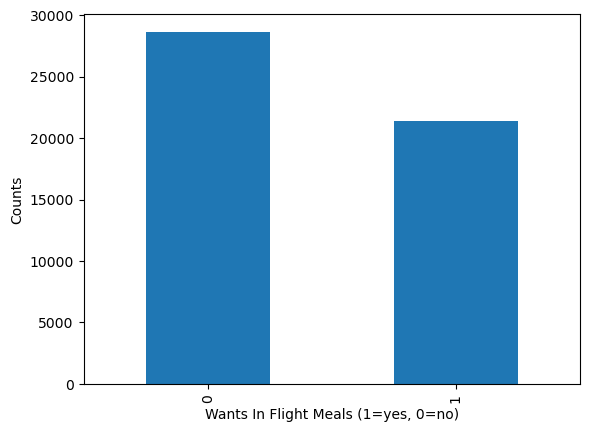

In [16]:
#Check the value counts of the categorical variables
counts = df["wants_in_flight_meals"].value_counts()
counts.plot(kind='bar')
plt.xlabel('Wants In Flight Meals (1=yes, 0=no)')
plt.ylabel('Counts')
plt.show()

In [17]:
#Check the value counts of the categorical variables
#There are too many unique values for Route for me to display in one bar chart
#Instead, let's look at the top 10 most frequent values
df['route'].value_counts().head(10)

route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
Name: count, dtype: int64

In [18]:
#Check the value counts of the categorical variables
#There are too many unique values for Booking Origin for me to display in one bar chart
#Instead, let's look at the top 10 most frequent values
df['booking_origin'].value_counts().head(10)

booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64

-----------------------------

## Data Preparation and Feature Engineering

We are going to develop and train a Random Forest model to predict customer bookings. Since Random Forest cannot handle categorical variables, we need to create dummy variables with binary values.

Additionally, I would like to create some new variables (origin, destination, total extras) by repurposing some of the data we have.

In [19]:
#Add 3 new variables to the dataset
df["origin"] = df["route"].str[:3]
df["destination"] = df["route"].str[3:]
df["total_extras"] = df[["wants_extra_baggage","wants_preferred_seat","wants_in_flight_meals"]].sum(axis=1)

In [20]:
#As was mentioned earlier, the route (origin and destination) and booking_origin variables have a lot of unique values
#If we were to create dummy variables for every unique value, the dimension of the dataset would increase substantially
#Instead, I am going to keep the values for the 10 most frequent values of each variable and label everything else "Other"
def top_n(s, n):
    """Keep the n most frequent values, group the rest as 'Other'."""
    keep = s.value_counts().nlargest(n).index
    return s.where(s.isin(keep), "Other")

In [21]:
#Update values for origin, destination, and booking_origin
df["origin"] = top_n(df["origin"], 10)
df["destination"] = top_n(df["destination"], 10)
df["booking_origin"] = top_n(df["booking_origin"], 10)

In [22]:
#Store target variable
y = df["booking_complete"]

#Drop target variable and route (now that it is redundant) and create dummy variables
X = df.drop(columns=["booking_complete", "route"])
X = pd.get_dummies(X, columns=["sales_channel", "trip_type", "booking_origin", "origin", "destination"], dtype=int)

In [23]:
X.shape

(50000, 48)

After creating the dummy variables, we now have 48 columns in the dataset

In [24]:
X.head(5)

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,total_extras,...,destination_KIX,destination_KUL,destination_MEL,destination_OOL,destination_Other,destination_PEN,destination_PER,destination_SIN,destination_SYD,destination_TPE
0,2,262,19,7,6,1,0,0,5.52,1,...,0,0,0,0,1,0,0,0,0,0
1,1,112,20,3,6,0,0,0,5.52,0,...,0,0,0,0,1,0,0,0,0,0
2,2,243,22,17,3,1,1,0,5.52,2,...,0,0,0,0,1,0,0,0,0,0
3,1,96,31,4,6,0,0,1,5.52,1,...,0,0,0,0,1,0,0,0,0,0
4,2,68,22,15,3,1,0,1,5.52,2,...,0,0,0,0,1,0,0,0,0,0


---------------

## Model Development

In [25]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, make_scorer, classification_report, ConfusionMatrixDisplay

In [26]:
#Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [27]:
#Define and fit Random Forest model using default parameters
base_rf = RandomForestClassifier()
base_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
#Predict test data using base model
base_y_pred = base_rf.predict(X_test)
base_y_pred_prob = base_rf.predict_proba(X_test)[:, 1]  # For ROC-AUC

In [29]:
#Calculate accuracy and ROC-AUC for base model
accuracy = accuracy_score(y_test, base_y_pred)
roc_auc = roc_auc_score(y_test, base_y_pred_prob)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")

Test Accuracy: 0.8476
Test ROC-AUC: 0.7690


### Parameter Tuning

In [30]:
#Complete hyper-parameter tuning using GridSearch
rf_params = dict(n_estimators = [100, 250, 500],
                 min_samples_split = [10, 20, 40, 50],
                  max_depth = [2,4,6,None])

#Initiate GridSearch object and fit it to training data
rf_gs = GridSearchCV(estimator=base_rf, param_grid=rf_params, scoring='f1', verbose=1, cv=5)
rf_gs.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [2, 4, ...], 'min_samples_split': [10, 20, ...], 'n_estimators': [100, 250, ...]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [31]:
rf_gs.best_params_

{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}

In [32]:
#Define Random Forest model using best parameters identified
best_rf = RandomForestClassifier(n_estimators=250, min_samples_split=10, max_depth=None)
best_rf.fit(X_train, y_train)

,n_estimators,250
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


---------------

## Model Predictions and Evaluation

In [33]:
#Predict test data
y_pred_gs = best_rf.predict(X_test)
y_pred_prob_gs = best_rf.predict_proba(X_test)[:, 1]  # For ROC-AUC

In [34]:
#Calculate accuracy and ROC-AUC for the best model
accuracy = accuracy_score(y_test, y_pred_gs)
roc_auc = roc_auc_score(y_test, y_pred_prob_gs)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")

Test Accuracy: 0.8505
Test ROC-AUC: 0.7797


In [35]:
#Cross-validation for accuracy and ROC-AUC
accuracy_scores = rf_gs.cv_results_['mean_test_score']
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

roc_auc_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring=make_scorer(roc_auc_score))
mean_roc_auc = np.mean(roc_auc_scores)
std_roc_auc = np.std(roc_auc_scores)

In [36]:
#Print CV Results
print(f"Cross-validation Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"Cross-validation ROC-AUC: {mean_roc_auc:.4f} ± {std_roc_auc:.4f}")

Cross-validation Accuracy: 0.0220 ± 0.0408
Cross-validation ROC-AUC: 0.5328 ± 0.0030


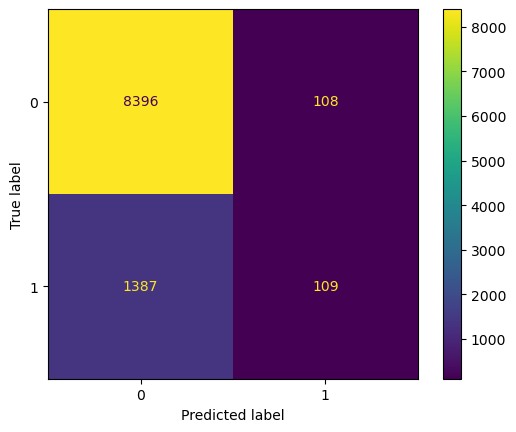

In [37]:
#Create Confusion Matrix for test predictions
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gs)
plt.show()

In [38]:
#Create classification report to check performance metrics of test predictions
print(classification_report(y_test, y_pred_gs))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.50      0.07      0.13      1496

    accuracy                           0.85     10000
   macro avg       0.68      0.53      0.52     10000
weighted avg       0.80      0.85      0.80     10000



In [39]:
#Probabilities
proba = best_rf.predict_proba(X_test)[:, 1]
print("\nHold-out ROC-AUC:", round(roc_auc_score(y_test, proba), 3),
      "| PR-AUC:", round(average_precision_score(y_test, proba), 3))


Hold-out ROC-AUC: 0.78 | PR-AUC: 0.367


-----------------

## Feature Importance

In [40]:
imp = pd.Series(best_rf.feature_importances_, index=X.columns)
perm = permutation_importance(best_rf, X_test, y_test, scoring="average_precision", n_repeats=5)
perm = pd.Series(perm.importances_mean, index=X.columns)

In [41]:
#Print top 10 features based on impurity
print("\nTop 10 (impurity):\n", imp.nlargest(10).round(3))


Top 10 (impurity):
 purchase_lead               0.159
length_of_stay              0.122
flight_hour                 0.118
flight_day                  0.075
flight_duration             0.062
booking_origin_Malaysia     0.057
num_passengers              0.047
booking_origin_Australia    0.041
total_extras                0.031
origin_PEN                  0.015
dtype: float64


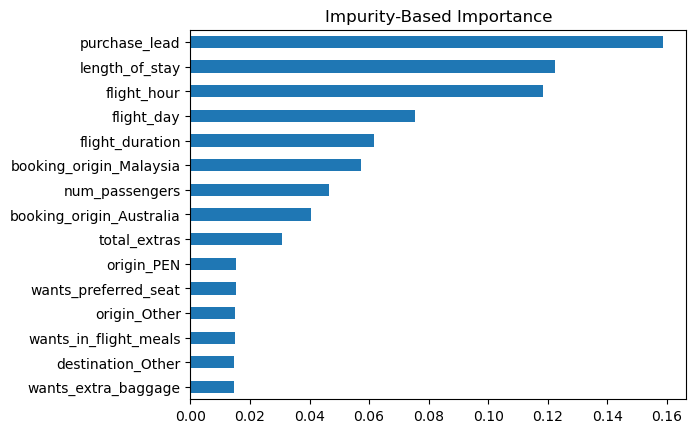

In [42]:
#Bar chart showing top 15 features based on impurity
imp.nlargest(15).sort_values().plot.barh()
plt.title("Impurity-Based Importance")
plt.show()

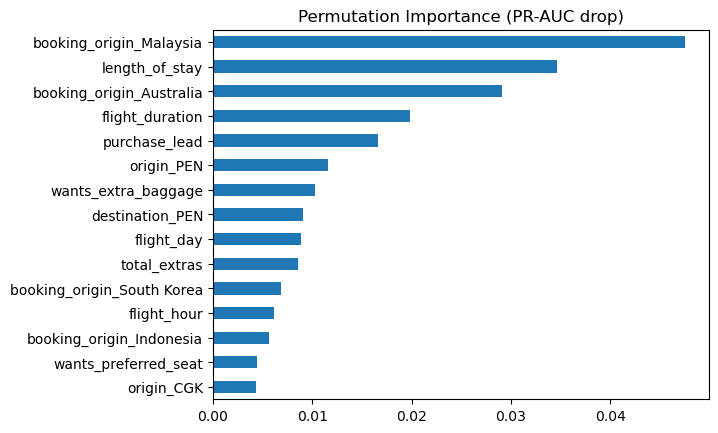

In [43]:
#Bar chart showing top 15 features based on permutation importance
perm.nlargest(15).sort_values().plot.barh()
plt.title("Permutation Importance (PR-AUC drop)")
plt.show()